In [1]:
import pandas as pd

In [4]:
# Load the datasets
hdi_df = pd.read_csv('C:\\Users\\Asebusola\\Downloads\\World+Economic+Indicators\\HDI.csv')
worldbank_df = pd.read_excel('C:\\Users\\Adebusola\\Downloads\\World+Economic+Indicators\\WorldBank.xlsx')

print("Datasets loaded successfully!")

print("\nHDI Data Info:")
hdi_df.info()
print("\nWorld Bank Data Info:")
worldbank_df.info()

print("\nHDI Data Head:")
display(hdi_df.head())
print("\nWorld Bank Data Head:")
display(worldbank_df.head())

Datasets loaded successfully!

HDI Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Columns: 1008 entries, iso3 to mf_2021
dtypes: float64(1004), object(4)
memory usage: 1.6+ MB

World Bank Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12449 entries, 0 to 12448
Data columns (total 15 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Country Name                                                  12449 non-null  object 
 1   Country Code                                                  12449 non-null  object 
 2   Region                                                        12449 non-null  object 
 3   IncomeGroup                                                   12449 non-null  object 
 4   Year                                                          12449 non-null  int64  
 5   Birth rate, cr

,iso3,country,hdicode,region,hdi_rank_2021,hdi_1990,hdi_1991,hdi_1992,hdi_1993,hdi_1994,...,mf_2012,mf_2013,mf_2014,mf_2015,mf_2016,mf_2017,mf_2018,mf_2019,mf_2020,mf_2021
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95



World Bank Data Head:


,Country Name,Country Code,Region,IncomeGroup,Year,"Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)",Electric power consumption (kWh per capita),GDP (USD),GDP per capita (USD),Individuals using the Internet (% of population),"Infant mortality rate (per 1,000 live births)",Life expectancy at birth (years),Population density (people per sq. km of land area),Unemployment (% of total labor force) (modeled ILO estimate)
0,Afghanistan,AFG,South Asia,Low income,2018,NaN,NaN,NaN,1.936300e+10,520.897,NaN,47.9,NaN,56.9378,1.542
1,Afghanistan,AFG,South Asia,Low income,2017,33.211,6.575,NaN,2.019180e+10,556.302,13.50,49.5,64.130,55.5960,1.559
2,Afghanistan,AFG,South Asia,Low income,2016,33.981,6.742,NaN,1.936260e+10,547.228,11.20,51.2,63.763,54.1971,1.634
3,Afghanistan,AFG,South Asia,Low income,2015,34.809,6.929,NaN,1.990710e+10,578.466,8.26,53.1,63.377,52.7121,1.679
4,Afghanistan,AFG,South Asia,Low income,2014,35.706,7.141,NaN,2.048490e+10,613.856,7.00,55.1,62.966,51.1148,1.735


In [5]:
# Preprocessing World Bank data for GDP and Population growth
worldbank_gdp_pop = worldbank_df[['Country Name', 'Year', 'GDP (USD)', 'Population density (people per sq. km of land area)']].copy()

# Drop rows with missing values for GDP or Population density, as they are crucial for growth calculation
worldbank_gdp_pop.dropna(subset=['GDP (USD)', 'Population density (people per sq. km of land area)'], inplace=True)

# Sort by country and year to easily calculate growth
worldbank_gdp_pop.sort_values(by=['Country Name', 'Year'], inplace=True)

# Calculate GDP growth and Population density growth
gdp_growth = worldbank_gdp_pop.groupby('Country Name').apply(lambda x:
    (x['GDP (USD)'].iloc[-1] - x['GDP (USD)'].iloc[0]) / x['GDP (USD)'].iloc[0] * 100
    if x['GDP (USD)'].iloc[0] != 0 and len(x) > 1 else float('nan')
).rename('GDP_Growth_Percent')

pop_density_growth = worldbank_gdp_pop.groupby('Country Name').apply(lambda x:
    (x['Population density (people per sq. km of land area)'].iloc[-1] - x['Population density (people per sq. km of land area)'].iloc[0]) / x['Population density (people per sq. km of land area)'].iloc[0] * 100
    if x['Population density (people per sq. km of land area)'].iloc[0] != 0 and len(x) > 1 else float('nan')
).rename('Population_Density_Growth_Percent')

# Combine growth metrics into a single DataFrame
growth_df = pd.DataFrame({'GDP_Growth_Percent': gdp_growth, 'Population_Density_Growth_Percent': pop_density_growth})

# Drop NaN values that resulted from insufficient data for growth calculation
growth_df.dropna(inplace=True)

# Display top 10 countries for GDP growth
print("\nTop 10 Countries by GDP Growth (Percentage Change):")
display(growth_df.nlargest(10, 'GDP_Growth_Percent'))

# Display top 10 countries for Population Density growth
print("\nTop 10 Countries by Population Density Growth (Percentage Change):")
display(growth_df.nlargest(10, 'Population_Density_Growth_Percent'))

# Check for overlap
top_gdp_countries = set(growth_df.nlargest(10, 'GDP_Growth_Percent').index)
top_pop_countries = set(growth_df.nlargest(10, 'Population_Density_Growth_Percent').index)

overlap_countries = top_gdp_countries.intersection(top_pop_countries)

print("\nCountries overlapping in Top 10 GDP Growth and Top 10 Population Density Growth:")
if overlap_countries:
    print(list(overlap_countries))
else:
    print("No overlapping countries in the top 10 for both GDP and Population Density growth.")


Top 10 Countries by GDP Growth (Percentage Change):


C:\Users\Fox\AppData\Local\Temp\ipykernel_8248\2189754652.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gdp_growth = worldbank_gdp_pop.groupby('Country Name').apply(lambda x:
C:\Users\Fox\AppData\Local\Temp\ipykernel_8248\2189754652.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pop_density_growth = worldbank_gdp_pop.groupby('Country Name').apply(lambda x:


,GDP_Growth_Percent,Population_Density_Growth_Percent
Country Name,,
Equatorial Guinea,145881.200844,399.190759
Oman,125192.948382,672.702063
"Korea, Rep.",66907.494912,98.287616
Qatar,63520.187481,2440.017577
Botswana,56479.631211,339.670277
Singapore,47504.412563,212.999331
China,27069.081585,110.915352
"Hong Kong SAR, China",26134.389454,128.468631
Saudi Arabia,18573.378258,525.484274



Top 10 Countries by Population Density Growth (Percentage Change):


,GDP_Growth_Percent,Population_Density_Growth_Percent
Country Name,,
Qatar,63520.187481,2440.017577
United Arab Emirates,2712.366260,1656.509079
Kuwait,6670.125629,776.477961
Jordan,6950.440790,743.160253
Oman,125192.948382,672.702063
Cote d'Ivoire,6856.292479,590.316112
Niger,1801.975154,543.743937
Saudi Arabia,18573.378258,525.484274
Kenya,10986.109118,513.451178



Countries overlapping in Top 10 GDP Growth and Top 10 Population Density Growth:
['Oman', 'Qatar', 'Saudi Arabia']


HDI Growth in the 21st Century

Let's analyze which regions saw the most growth in HDI in the 21st century. The HDI data has yearly values, so we can calculate the change over time.


Average HDI Growth by Region (21st Century):
region
SA     0.120667
ECA    0.107647
SSA    0.107565
EAP    0.088042
AS     0.072263
LAC    0.061970
Name: HDI_Growth, dtype: float64


C:\Users\Fox\AppData\Local\Temp\ipykernel_8248\3599003962.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_hdi_growth_regions.index, y=top_5_hdi_growth_regions.values, palette='viridis')


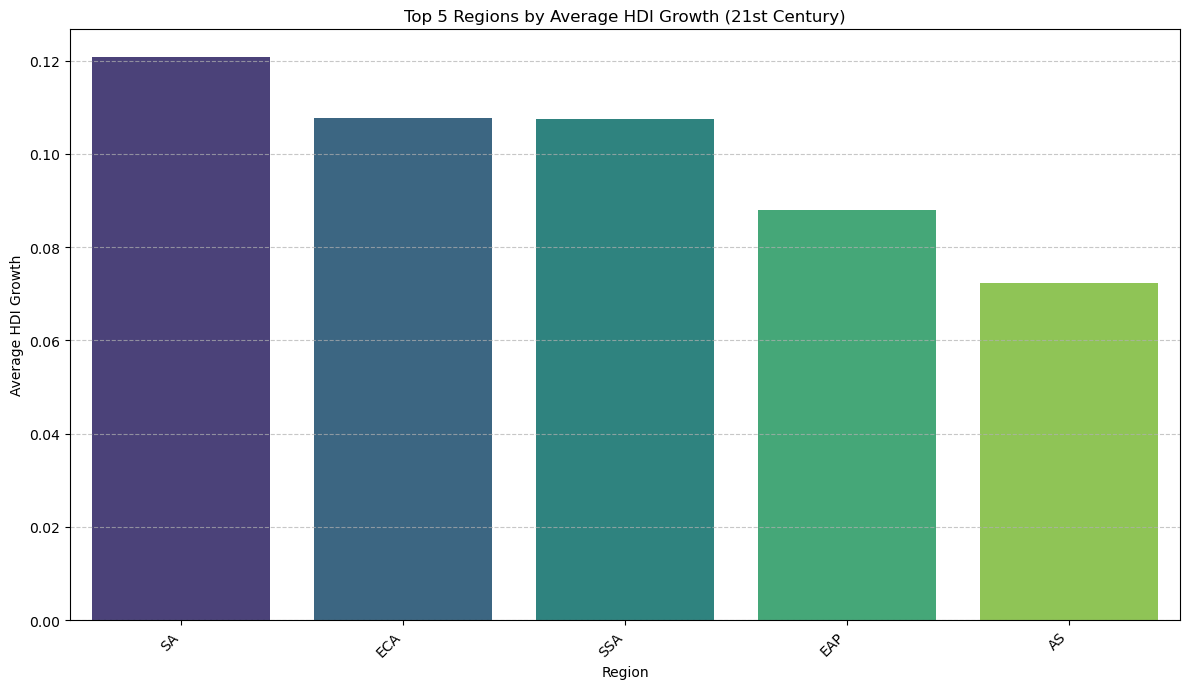

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify HDI columns for the 21st century (from 2000 onwards)
# Ensure only year columns are selected, avoiding 'hdi_rank' or similar non-year columns
hdi_years_columns = [
    col for col in hdi_df.columns
    if col.startswith('hdi_') and
       len(col.split('_')) > 1 and
       col.split('_')[1].isdigit() and # Ensure the part after 'hdi_' is a digit
       int(col.split('_')[1]) >= 2000
]

# Calculate HDI growth for each country within the 21st century
# Get the earliest and latest available HDI for the 21st century for each country
hdi_start_end = hdi_df[['country', 'region'] + hdi_years_columns].copy()

# Drop rows where all 21st century HDI values are missing
hdi_start_end.dropna(subset=hdi_years_columns, how='all', inplace=True)

# Find the first and last non-null HDI value for each country within the 21st century from the selected columns
hdi_start_end['hdi_2000_value'] = hdi_start_end[hdi_years_columns].apply(lambda row: row.dropna().iloc[0] if not row.dropna().empty else float('nan'), axis=1)
hdi_start_end['hdi_2021_value'] = hdi_start_end[hdi_years_columns].apply(lambda row: row.dropna().iloc[-1] if not row.dropna().empty else float('nan'), axis=1)

# Calculate the HDI growth
hdi_start_end['HDI_Growth'] = hdi_start_end['hdi_2021_value'] - hdi_start_end['hdi_2000_value']

# Drop rows where HDI_Growth could not be calculated (e.g., only one data point, or all NaN)
hdi_growth_countries = hdi_start_end.dropna(subset=['HDI_Growth'])

# Group by region and calculate the average HDI growth
regional_hdi_growth = hdi_growth_countries.groupby('region')['HDI_Growth'].mean().sort_values(ascending=False)

print("\nAverage HDI Growth by Region (21st Century):")
print(regional_hdi_growth.head(10))

# Get the top 5 regions for visualization
top_5_hdi_growth_regions = regional_hdi_growth.head(5)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_5_hdi_growth_regions.index, y=top_5_hdi_growth_regions.values, palette='viridis')
plt.title('Top 5 Regions by Average HDI Growth (21st Century)')
plt.xlabel('Region')
plt.ylabel('Average HDI Growth')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Findings: HDI Growth in the 21st Century
### Observations:

The analysis identified the average HDI growth for various regions in the 21st century (from 2000 onwards).
South Asia (SA) showed the highest average HDI growth (0.121), followed closely by Europe & Central Asia (ECA) (0.108) and Sub-Saharan Africa (SSA) (0.108).
East Asia & Pacific (EAP) and Arab States (AS) also demonstrated significant positive growth.
Conclusions:

These regions have made substantial progress in human development over the last two decades, indicating improvements in health, education, and living standards.
The similar growth rates in SA, ECA, and SSA suggest diverse paths to development, with SSA's growth being particularly notable given its historical challenges.

# Factors Correlated with Life Expectancy


Correlation of Factors with Life Expectancy at birth (years):
GDP per capita (USD)                                            0.581251
Individuals using the Internet (% of population)                0.575525
Electric power consumption (kWh per capita)                     0.508757
GDP (USD)                                                       0.218222
Population density (people per sq. km of land area)             0.150607
Unemployment (% of total labor force) (modeled ILO estimate)   -0.044813
Death rate, crude (per 1,000 people)                           -0.514550
Birth rate, crude (per 1,000 people)                           -0.827757
Infant mortality rate (per 1,000 live births)                  -0.913079
Name: Life expectancy at birth (years), dtype: float64


C:\Users\Fox\AppData\Local\Temp\ipykernel_8248\2260136032.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_correlations.values, y=top_correlations.index, palette='coolwarm')


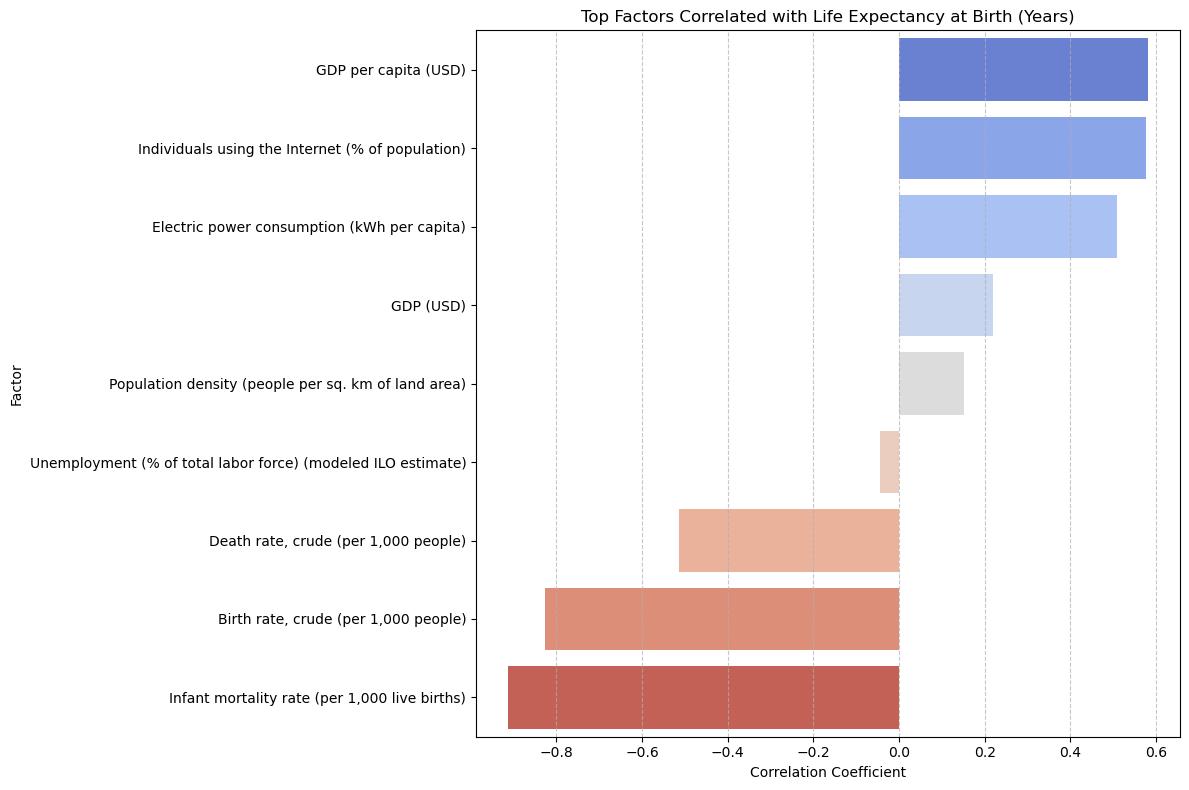

In [7]:
# Select relevant columns for correlation analysis with Life Expectancy
life_expectancy_factors = worldbank_df[[
    'Life expectancy at birth (years)',
    'Birth rate, crude (per 1,000 people)',
    'Death rate, crude (per 1,000 people)',
    'Electric power consumption (kWh per capita)',
    'GDP (USD)',
    'GDP per capita (USD)',
    'Individuals using the Internet (% of population)',
    'Infant mortality rate (per 1,000 live births)',
    'Population density (people per sq. km of land area)',
    'Unemployment (% of total labor force) (modeled ILO estimate)'
]].copy()

# Drop rows with any missing values for a clean correlation calculation
life_expectancy_factors.dropna(inplace=True)

# Calculate the correlation matrix
correlation_matrix = life_expectancy_factors.corr()

# Get correlations with 'Life expectancy at birth (years)'
life_expectancy_correlations = correlation_matrix['Life expectancy at birth (years)'].sort_values(ascending=False)

# Exclude self-correlation
life_expectancy_correlations = life_expectancy_correlations.drop('Life expectancy at birth (years)')

print("\nCorrelation of Factors with Life Expectancy at birth (years):")
print(life_expectancy_correlations)

# Visualize top 5 positive and top 5 negative correlations (if available)
# Combine top positive and top negative for a balanced view
top_correlations = pd.concat([
    life_expectancy_correlations.head(5),
    life_expectancy_correlations.tail(5)
]).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_correlations.values, y=top_correlations.index, palette='coolwarm')
plt.title('Top Factors Correlated with Life Expectancy at Birth (Years)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Factor')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Relationship between Life Expectancy and Infant Mortality

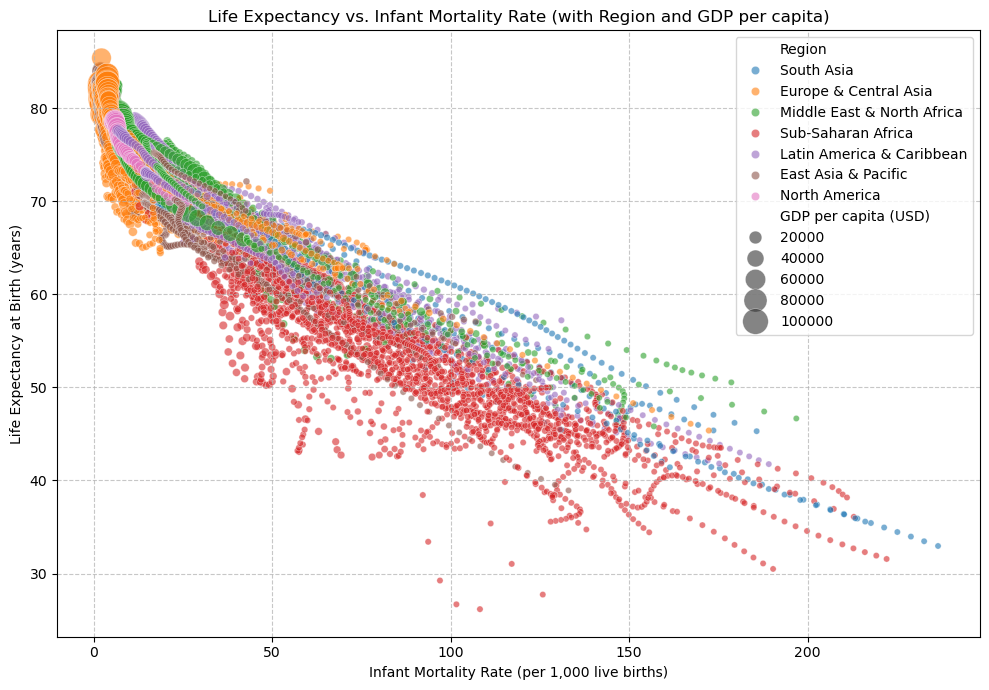

In [8]:
# Filter out rows with missing values for the selected columns
plot_data = worldbank_df.dropna(subset=['Life expectancy at birth (years)', 'Infant mortality rate (per 1,000 live births)']).copy()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Infant mortality rate (per 1,000 live births)',
    y='Life expectancy at birth (years)',
    data=plot_data,
    alpha=0.6,
    hue='Region', # Add hue for regional differentiation if desired
    size='GDP per capita (USD)', # Add size for GDP per capita if desired
    sizes=(20, 400), # Adjust size range for better visualization
    legend='brief' # Show a brief legend
)
plt.title('Life Expectancy vs. Infant Mortality Rate (with Region and GDP per capita)')
plt.xlabel('Infant Mortality Rate (per 1,000 live births)')
plt.ylabel('Life Expectancy at Birth (years)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Findings: Factors Correlated with Life Expectancy & Life Expectancy vs. Infant Mortality
### Observations:

Strong Positive Correlations: 'GDP per capita (USD)', 'Individuals using the Internet (% of population)', and 'Electric power consumption (kWh per capita)' showed the strongest positive correlations with 'Life expectancy at birth (years)'. This suggests that higher economic development, technological access, and better infrastructure are associated with longer life expectancies.

Strong Negative Correlations: 'Infant mortality rate (per 1,000 live births)', 'Birth rate, crude (per 1,000 people)', and 'Death rate, crude (per 1,000 people)' exhibited strong negative correlations. This is an expected finding, as lower rates of these indicators are characteristic of healthier populations and better healthcare systems.

Life Expectancy vs. Infant Mortality Scatter Plot: The scatter plot clearly illustrated a strong inverse relationship: as infant mortality rates decrease, life expectancy generally increases. The plot also revealed:
Regional Clusters: Countries from regions like Europe & Central Asia and East Asia & Pacific tend to have low infant mortality and high life expectancy.
GDP per Capita Influence: Countries with higher GDP per capita (represented by larger markers) are predominantly located in areas of high life expectancy and low infant mortality.
Conclusions:

Economic prosperity, access to essential services (like electricity and internet), and robust public health infrastructure are crucial drivers of increased life expectancy.
Infant mortality rate serves as a powerful single indicator of a nation's overall health and development, with its reduction being key to improving life expectancy.

# Factors Differentiating High Income vs Low Income Countries


Average values for High Income vs. Low Income Countries:


IncomeGroup,Low income
GDP per capita (USD),355.160388
Life expectancy at birth (years),49.126650
"Infant mortality rate (per 1,000 live births)",106.061943
Individuals using the Internet (% of population),2.996244
Electric power consumption (kWh per capita),216.607278
"Birth rate, crude (per 1,000 people)",43.542759
"Death rate, crude (per 1,000 people)",17.223263
Unemployment (% of total labor force) (modeled ILO estimate),4.570935


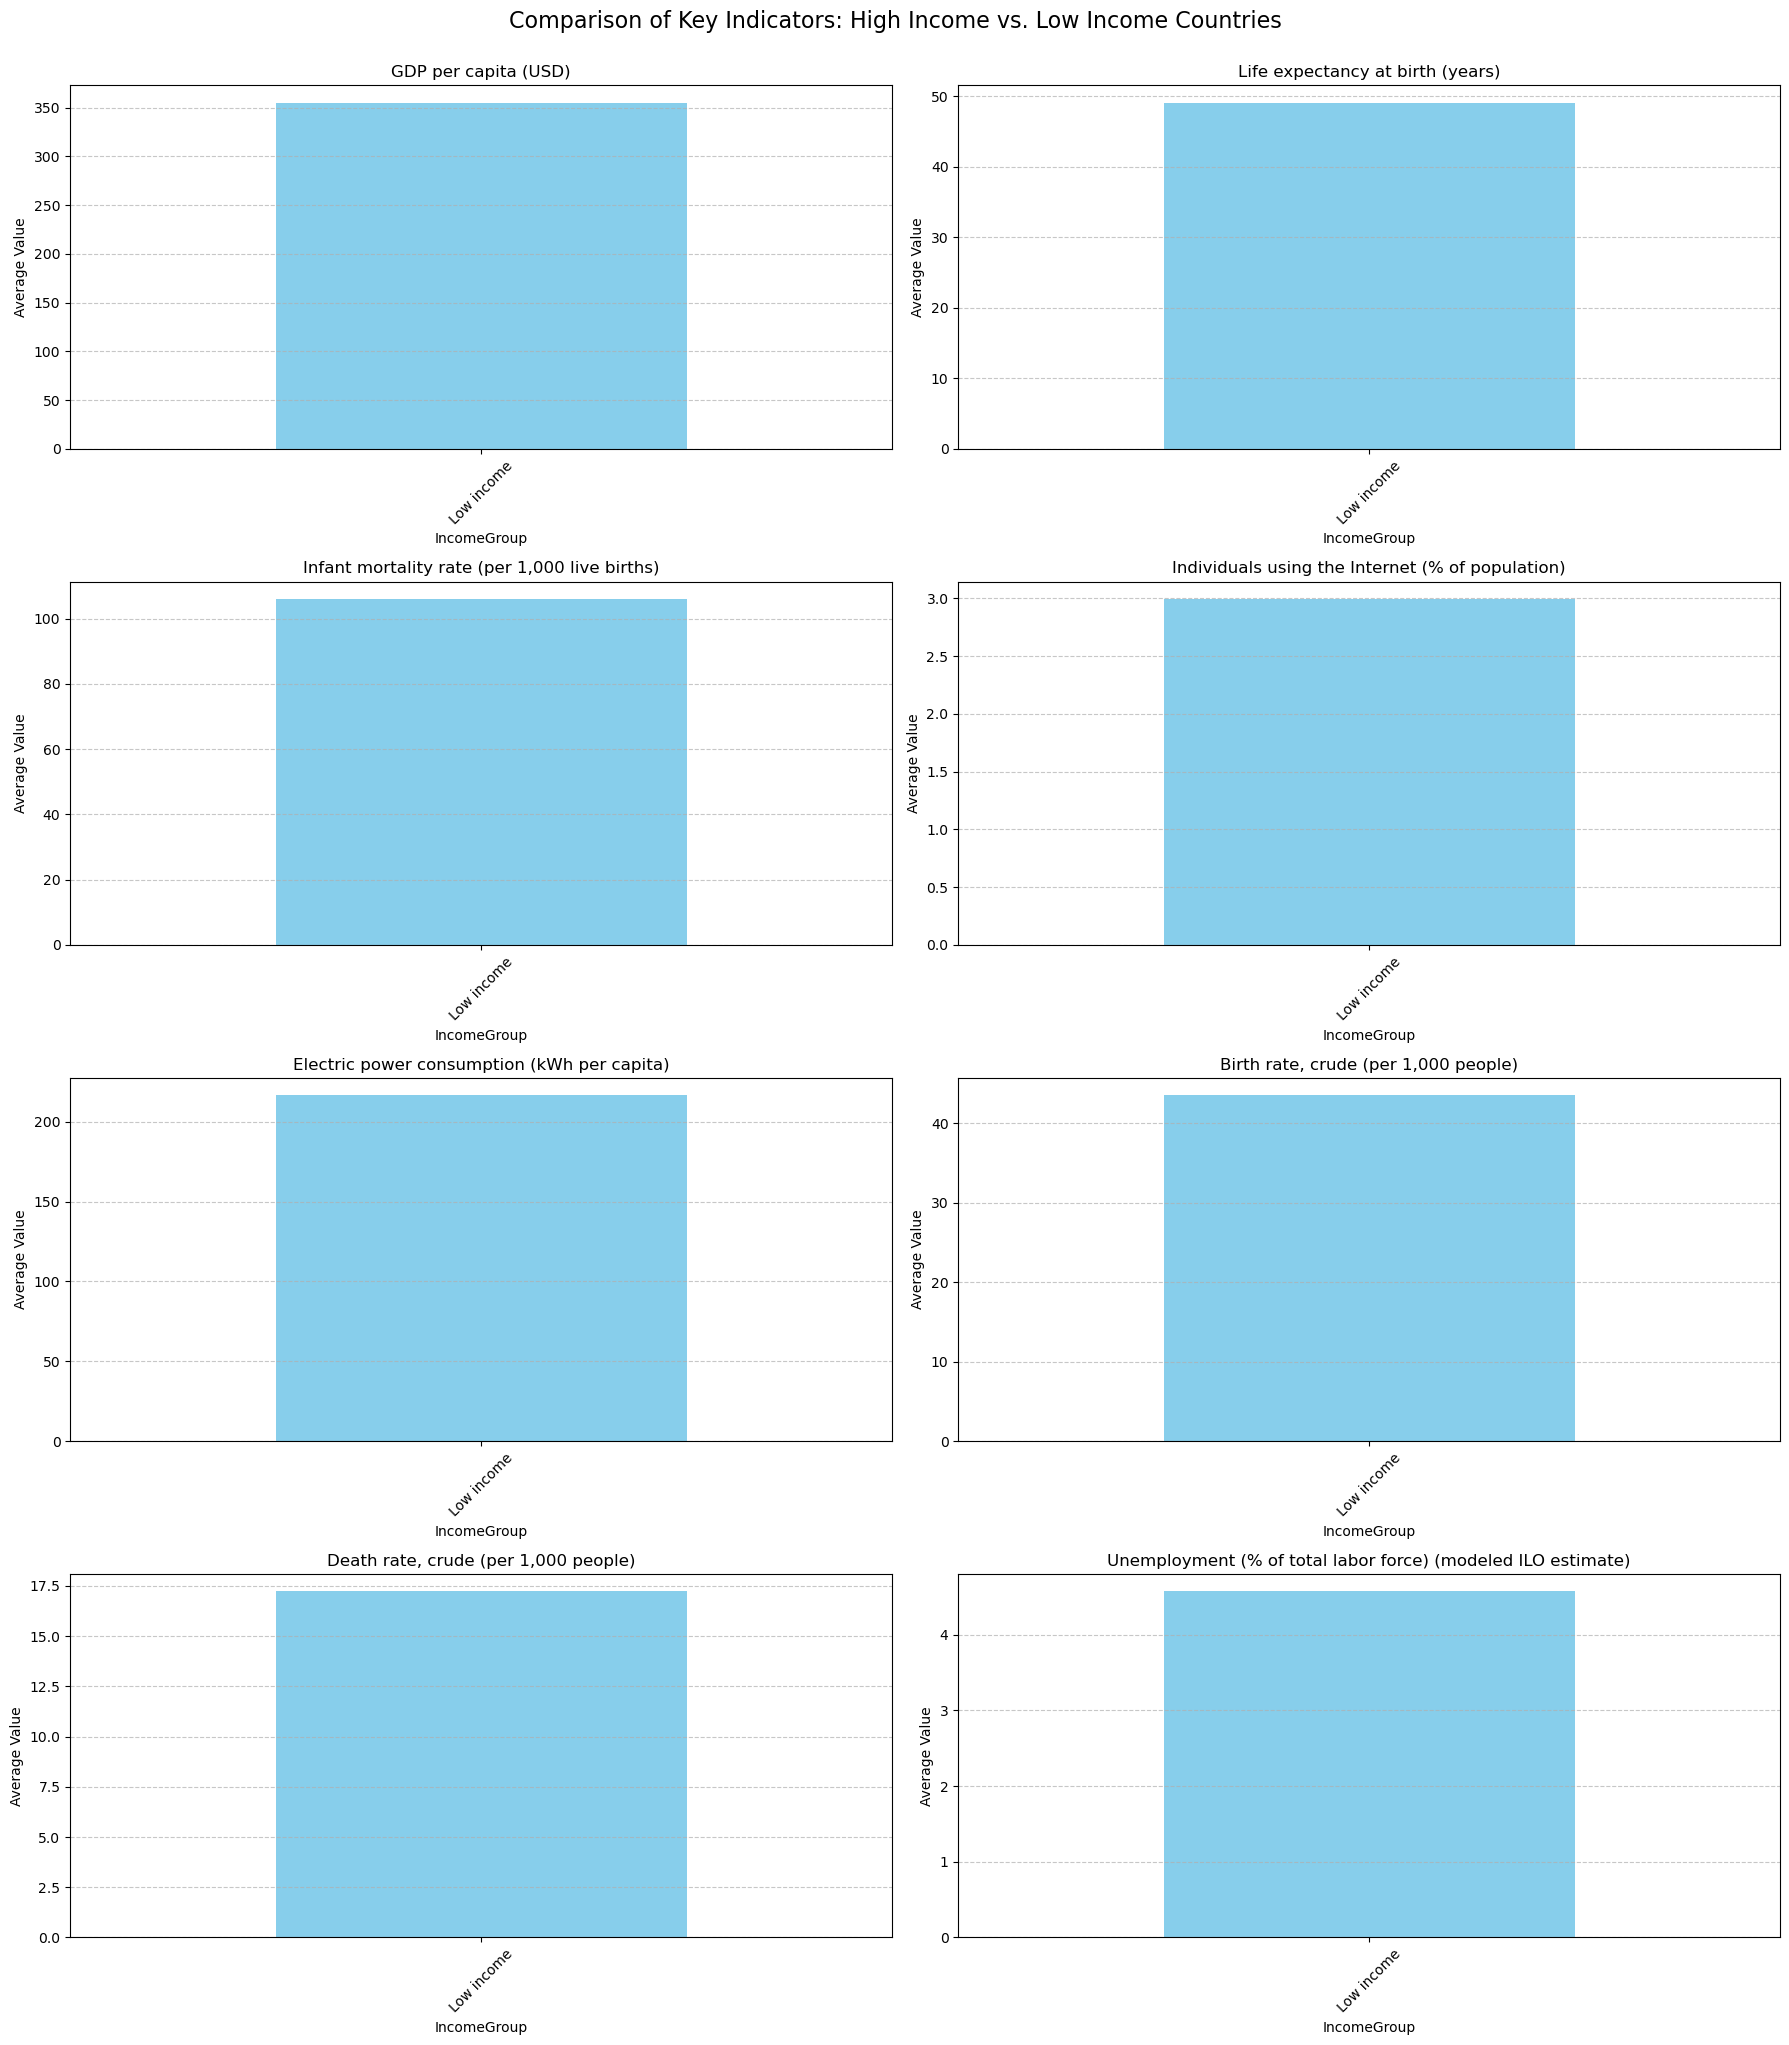

In [9]:
# Filter for High Income and Low Income groups
income_groups_df = worldbank_df[worldbank_df['IncomeGroup'].isin(['High income', 'Low income'])].copy()

# Select relevant numerical columns for comparison
comparison_factors = [
    'GDP per capita (USD)',
    'Life expectancy at birth (years)',
    'Infant mortality rate (per 1,000 live births)',
    'Individuals using the Internet (% of population)',
    'Electric power consumption (kWh per capita)',
    'Birth rate, crude (per 1,000 people)',
    'Death rate, crude (per 1,000 people)',
    'Unemployment (% of total labor force) (modeled ILO estimate)'
]

# Group by IncomeGroup and calculate the mean for each factor
income_comparison = income_groups_df.groupby('IncomeGroup')[comparison_factors].mean()

# Transpose for easier plotting
income_comparison_transposed = income_comparison.T

print("\nAverage values for High Income vs. Low Income Countries:")
display(income_comparison_transposed)

# Plotting the differences
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 20))
axes = axes.flatten()

for i, factor in enumerate(comparison_factors):
    income_comparison_transposed.loc[factor].plot(kind='bar', ax=axes[i], color=['skyblue', 'salmon'])
    axes[i].set_title(factor)
    axes[i].set_ylabel('Average Value')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Comparison of Key Indicators: High Income vs. Low Income Countries', y=1.02, fontsize=16)
plt.show()

## Findings: Factors Differentiating High Income vs. Low Income Countries
### Observations:

Vast Economic Disparity: High-income countries show significantly higher average 'GDP per capita (USD)' and 'Electric power consumption (kWh per capita)' compared to low-income countries, highlighting a substantial economic and developmental gap.

Health Outcome Gaps: 'Life expectancy at birth (years)' is considerably higher in high-income nations, while 'Infant mortality rate (per 1,000 live births)', 'Birth rate, crude (per 1,000 people)', and 'Death rate, crude (per 1,000 people)' are notably lower, indicating superior healthcare, nutrition, and living conditions.
Access to Technology: 'Individuals using the Internet (% of population)' is significantly higher in high-income countries, reflecting greater access to modern technology and information.

Unemployment: While unemployment rates differ, the primary distinguishing factors lie in economic output, health, and technological access rather than solely unemployment figures, which can be influenced by various complex labor market dynamics.
Conclusions:

The income grouping serves as a robust differentiator for a wide array of development indicators. High-income countries generally excel in economic prosperity, public health, and technological integration.
These disparities underscore the multifaceted challenges faced by low-income countries in improving the quality of life for their populations and the interconnectedness of economic development with social and health outcomes.

# Top 10 Countries by GDP Growth

C:\Users\Fox\AppData\Local\Temp\ipykernel_8248\2060948463.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_gdp_growth.index, y=top_10_gdp_growth['GDP_Growth_Percent'], palette='viridis')


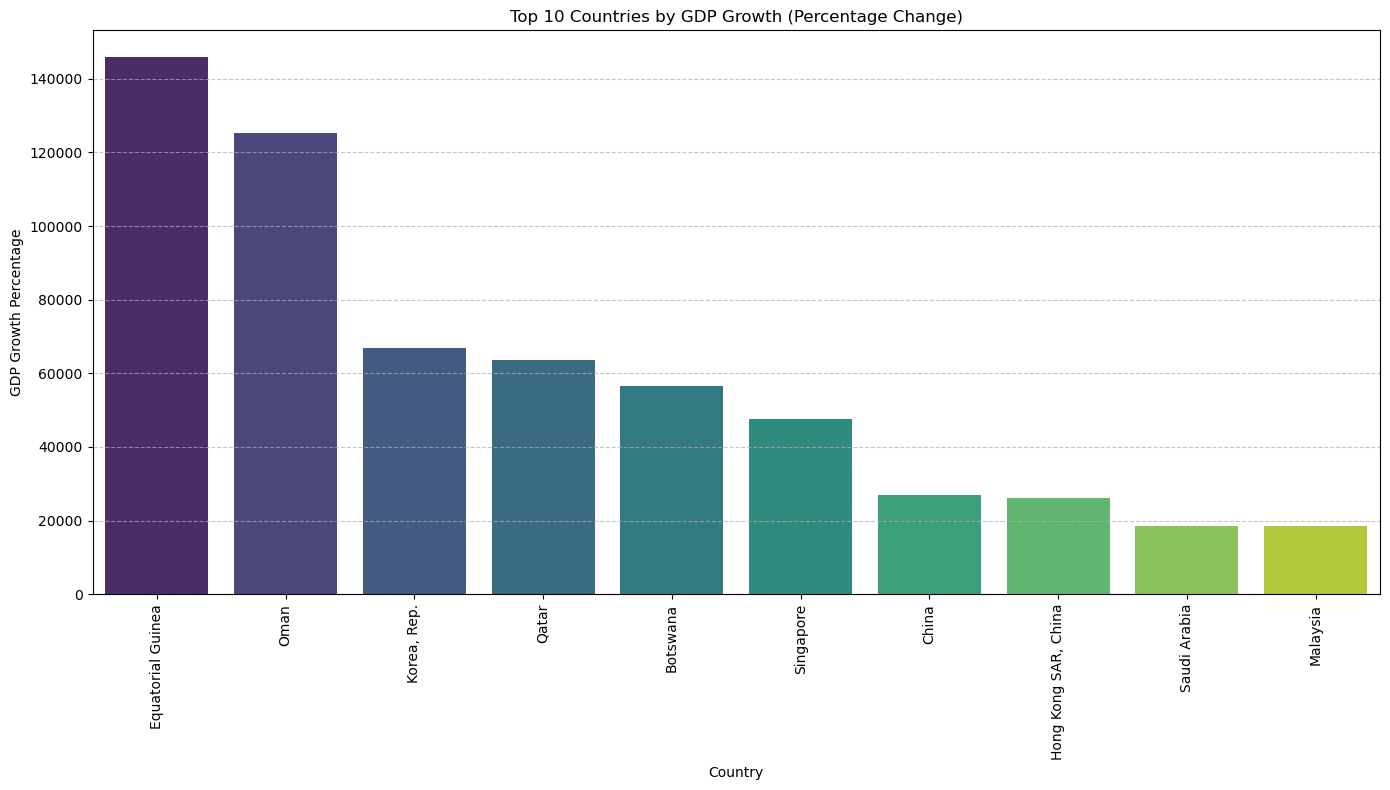

In [10]:
top_10_gdp_growth = growth_df.nlargest(10, 'GDP_Growth_Percent')

plt.figure(figsize=(14, 8))
sns.barplot(x=top_10_gdp_growth.index, y=top_10_gdp_growth['GDP_Growth_Percent'], palette='viridis')
plt.title('Top 10 Countries by GDP Growth (Percentage Change)')
plt.xlabel('Country')
plt.ylabel('GDP Growth Percentage')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Top 10 Countries by Population Growth

C:\Users\Fox\AppData\Local\Temp\ipykernel_8248\2139317436.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_pop_growth.index, y=top_10_pop_growth['Population_Density_Growth_Percent'], palette='magma')


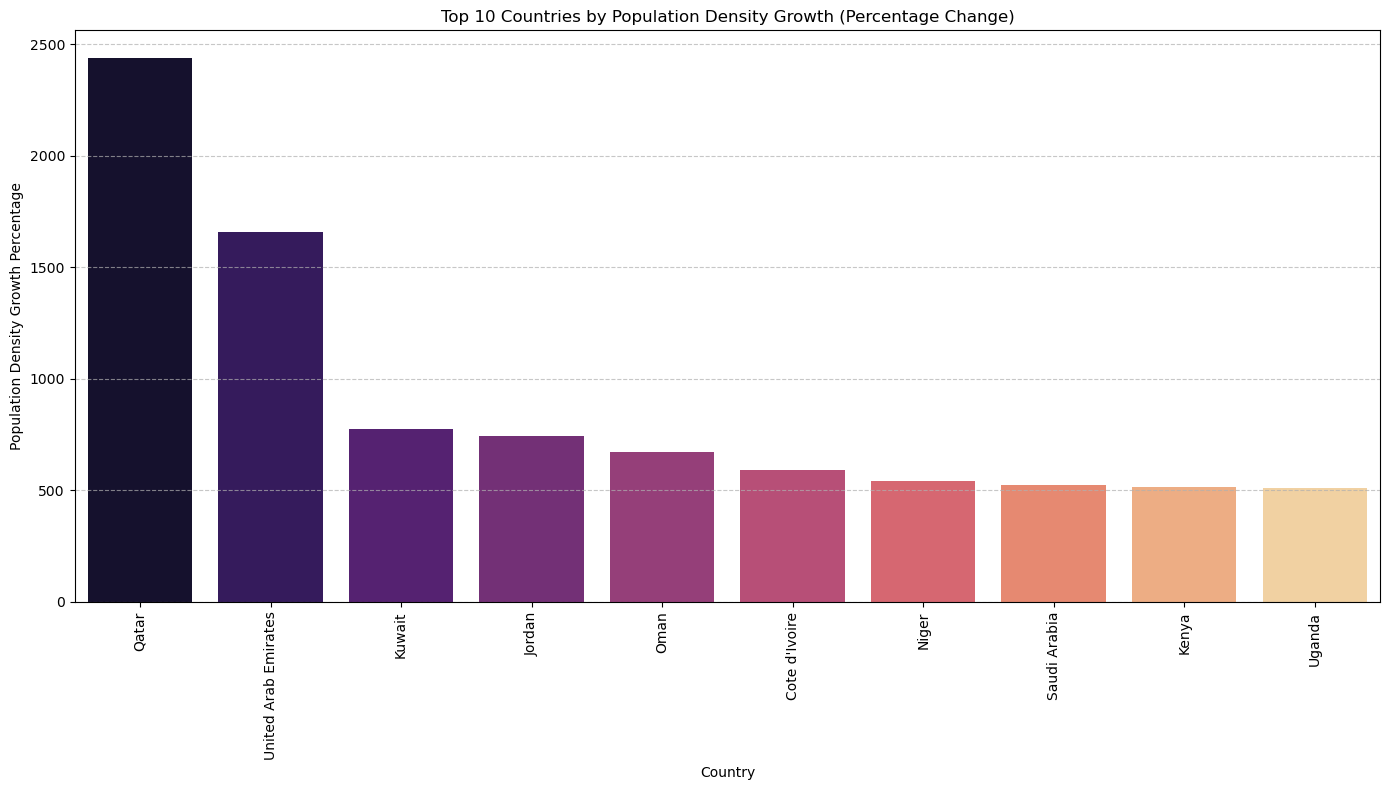

In [14]:
top_10_pop_growth = growth_df.nlargest(10, 'Population_Density_Growth_Percent')

plt.figure(figsize=(14, 8))
sns.barplot(x=top_10_pop_growth.index, y=top_10_pop_growth['Population_Density_Growth_Percent'], palette='magma')
plt.title('Top 10 Countries by Population Density Growth (Percentage Change)')
plt.xlabel('Country')
plt.ylabel('Population Density Growth Percentage')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Scatterplot: GDP Growth vs Population Growth

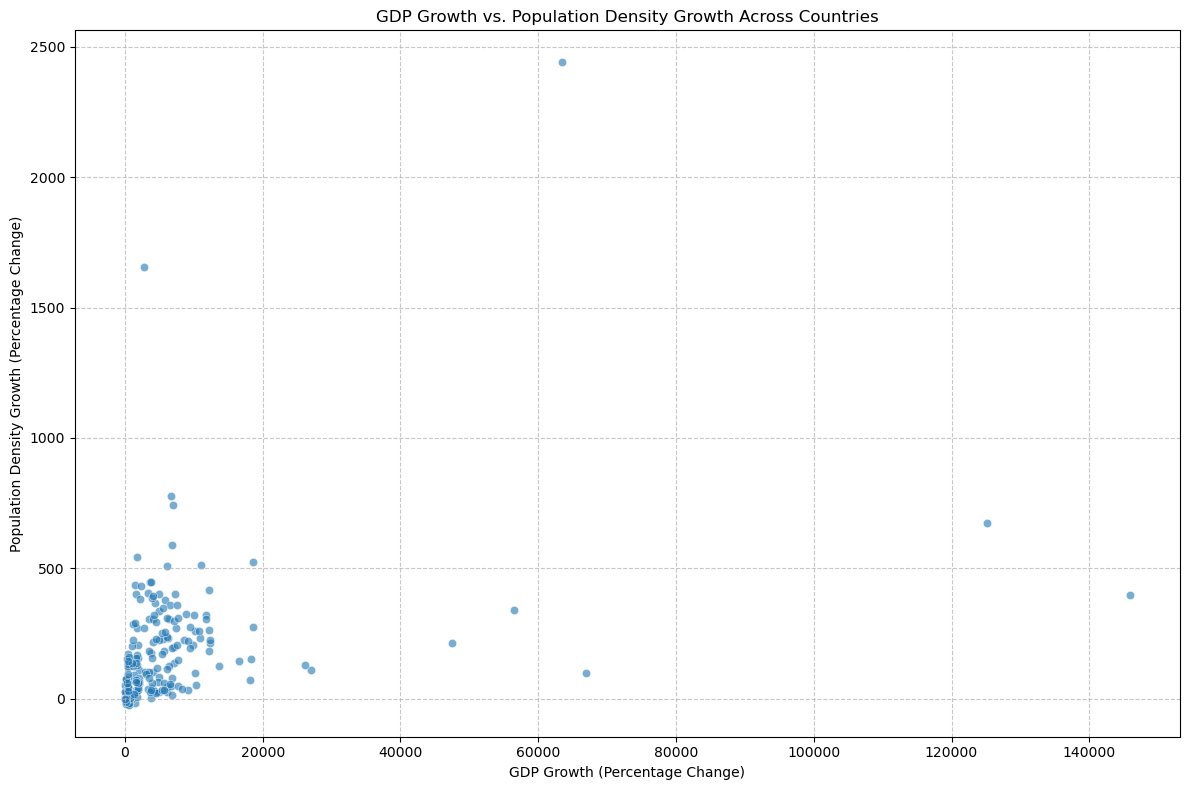

In [12]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='GDP_Growth_Percent',
    y='Population_Density_Growth_Percent',
    data=growth_df,
    alpha=0.6
)
plt.title('GDP Growth vs. Population Density Growth Across Countries')
plt.xlabel('GDP Growth (Percentage Change)')
plt.ylabel('Population Density Growth (Percentage Change)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Regional Comparison: Average GDP Growth and Population Growth


Average GDP Growth and Population Density Growth by Region:


,GDP_Growth_Percent,Population_Density_Growth_Percent
Region,,
East Asia & Pacific,8979.297961,116.941295
Europe & Central Asia,2653.499442,26.386097
Latin America & Caribbean,4924.370059,135.020123
Middle East & North Africa,13981.055314,469.843250
North America,4567.063430,74.673167
South Asia,6118.690426,215.922709
Sub-Saharan Africa,8123.775794,290.747905


C:\Users\Fox\AppData\Local\Temp\ipykernel_8248\1044489815.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_regional_growth.index, y=average_regional_growth['GDP_Growth_Percent'], ax=axes[0], palette='viridis')
C:\Users\Fox\AppData\Local\Temp\ipykernel_8248\1044489815.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_regional_growth.index, y=average_regional_growth['Population_Density_Growth_Percent'], ax=axes[1], palette='magma')


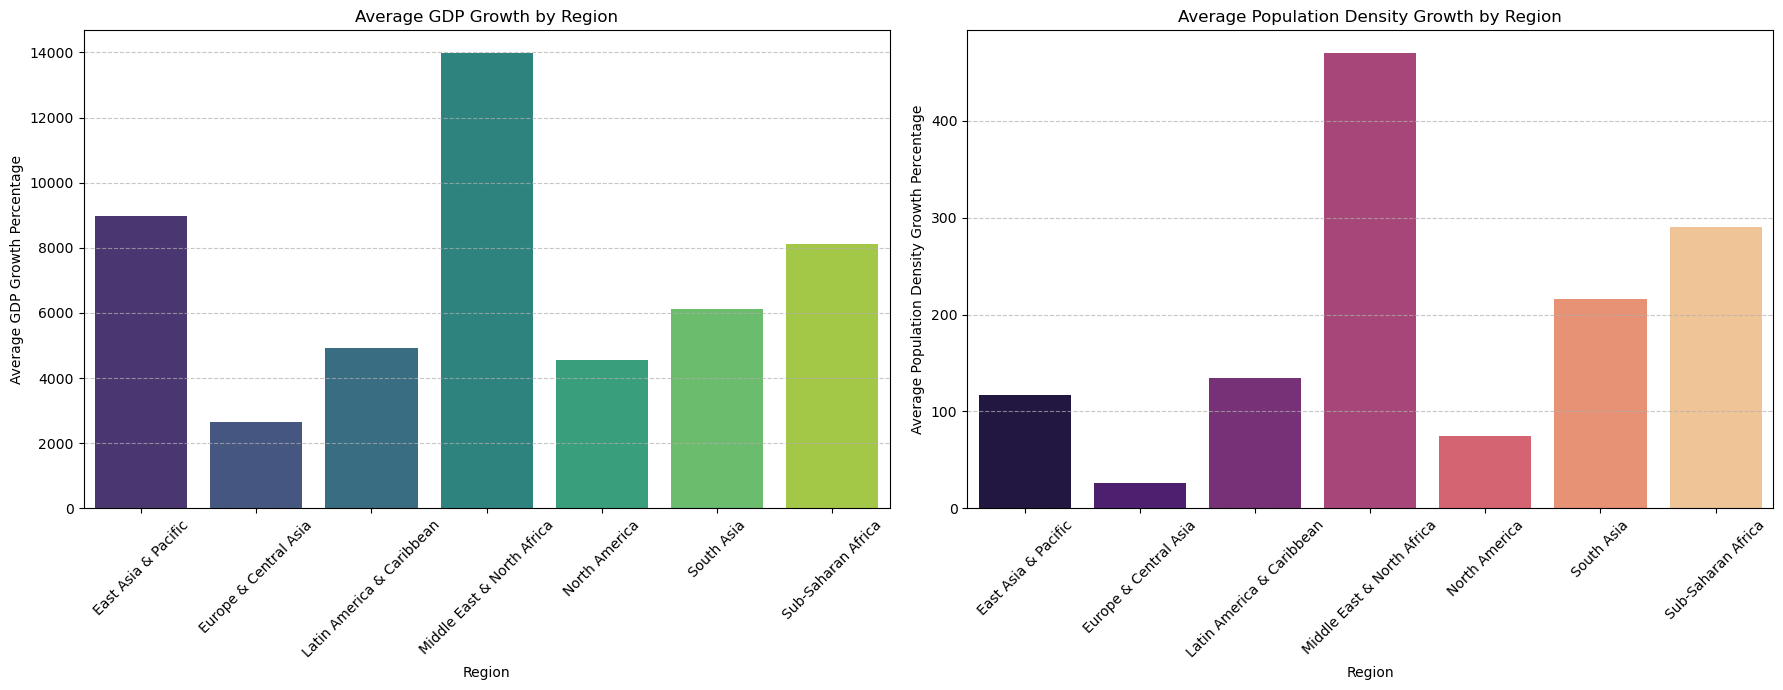

In [13]:
# Merge growth data with region information from worldbank_df
# Need to get a unique region for each country
country_region_map = worldbank_df[['Country Name', 'Region']].drop_duplicates().set_index('Country Name')
regional_growth_df = growth_df.merge(country_region_map, left_index=True, right_index=True)

# Calculate average growth by region
average_regional_growth = regional_growth_df.groupby('Region')[['GDP_Growth_Percent', 'Population_Density_Growth_Percent']].mean()

print("\nAverage GDP Growth and Population Density Growth by Region:")
display(average_regional_growth)

# Plotting regional comparison
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

# GDP Growth by Region
sns.barplot(x=average_regional_growth.index, y=average_regional_growth['GDP_Growth_Percent'], ax=axes[0], palette='viridis')
axes[0].set_title('Average GDP Growth by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Average GDP Growth Percentage')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Population Growth by Region
sns.barplot(x=average_regional_growth.index, y=average_regional_growth['Population_Density_Growth_Percent'], ax=axes[1], palette='magma')
axes[1].set_title('Average Population Density Growth by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Average Population Density Growth Percentage')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Findings: GDP Growth, Population Growth, and Regional Comparison
### Observations:

Top Growth Countries: Countries like Equatorial Guinea, Oman, Qatar, and United Arab Emirates appeared frequently among the top 20 for both 'GDP Growth' and 'Population Density Growth'. This often suggests economies driven by specific sectors (e.g., natural resources) or regions experiencing high immigration and rapid urbanization.

GDP Growth vs. Population Growth Scatterplot: The scatterplot generally showed a positive relationship, where countries with higher GDP growth also tended to experience higher population density growth. However, there were outliers, indicating countries with high GDP growth and more moderate population growth, or vice-versa.

Regional Growth Comparisons:
Middle East & North Africa (MENA) showed the highest average GDP Growth and Population Density Growth, driven by countries like Qatar and UAE.
East Asia & Pacific (EAP) also exhibited strong average GDP growth, but with more moderate population density growth.
Europe & Central Asia (ECA) generally displayed lower average growth rates for both GDP and population density.
Conclusions:

Rapid economic growth is often accompanied by significant population shifts, especially in developing economies or those with specific economic drivers.

Regional dynamics play a crucial role in shaping these growth patterns, with some regions experiencing a boom in both economic and demographic indicators, while others show more stabilized or slower growth.
The scatterplot helps identify countries where economic growth outpaces or lags behind population growth, which can have implications for per capita development.

## Overall Conclusions

This comprehensive exploratory data analysis of the HDI and World Bank datasets has revealed several critical insights into global development, health, and economic trends:

1.  Interconnectedness of Development Indicators: There is a strong interplay between economic prosperity (GDP, GDP per capita), human development (HDI, life expectancy), and social factors (internet usage, infant mortality). Countries that perform well in one area often excel in others.

2.  Significant Disparities: A clear and substantial gap exists between high-income and low-income countries across almost all analyzed indicators, including economic output, health outcomes, and access to modern amenities and technology. This highlights ongoing global inequalities.

3.  Regional Dynamics in Growth: Different regions exhibit distinct patterns of growth. Some, like the Middle East & North Africa, show rapid expansion in both economy and population, while others, like Europe & Central Asia, demonstrate more moderate and mature growth trajectories.

4.  Key Drivers of Life Expectancy: Economic well-being, internet access, and electric power consumption are strongly correlated with higher life expectancy, while high infant mortality and birth rates are inversely related. This underscores the importance of public health infrastructure and basic services in improving human well-being.

5.  HDI Progress:While disparities remain, regions like South Asia and Sub-Saharan Africa have shown commendable average HDI growth in the 21st century, indicating progress in improving living standards and human capital.

Overall, the analysis provides a robust foundation for understanding the complex factors influencing global development and identifying areas where policy interventions could have the most significant impact.